In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr


# generate true Us

In [2]:
n_subs = 24
n_parcel = 16
n_voxels  = 40
n_tasks = 20


Us = sim.generate_Us(s= n_subs, k = n_parcel, p = n_voxels, type= 'hard')

# Generate Vtrain

In [3]:
# def generate_V(n_tasks, n_parcels, seed=None):
#     if seed is not None:
#         np.random.seed(seed)
#     V = np.zeros((n_tasks, n_parcels))

#     for task in range(n_tasks):
#         if task < 5 and task < n_tasks:
#             # Activate a distinct parcel for each task with strong activation
#             parcel = task % n_parcels  # Ensure parcel index is within bounds
#             V[task, parcel] = 1.0 + np.random.uniform(-0.3, 0.3)  # Add noise

#         elif 5 <= task < 10 and task < n_tasks:
#             # Activate three parcels with decreasing strengths
#             parcel_1 = (task * 3) % n_parcels
#             parcel_2 = (parcel_1 + 3) % n_parcels
#             parcel_3 = (parcel_2 + 3) % n_parcels
#             V[task, [parcel_1, parcel_2, parcel_3]] = [
#                 0.8 + np.random.uniform(-0.3, 0.3),
#                 0.6 + np.random.uniform(-0.3, 0.3),
#                 0.4 + np.random.uniform(-0.3, 0.3)
#             ]
#         else:
#             # Randomly activate five parcels with unique patterns
#             active_parcels = np.random.choice(n_parcels, size=5, replace=False)
#             base_strength = 0.7
#             for i, parcel in enumerate(active_parcels):
#                 V[task, parcel] = base_strength + (0.2 * i) + np.random.uniform(-0.2, 0.2)
#                 base_strength -= 0.1
#     return V

# V = generate_V(n_tasks=20, n_parcels = 16, seed=1)

# # Visualize the V matrix
# plt.imshow(V)




-4.440892098500626e-16
15


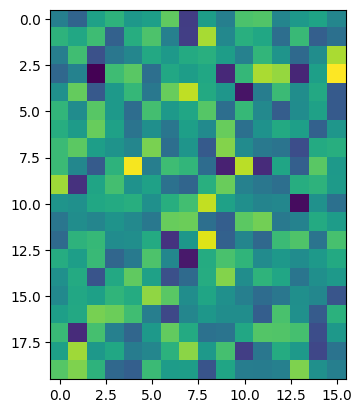

In [4]:
# generate Vs from normal distribution
Vs = np.random.normal(0,1,(n_tasks,n_parcel))

# subtract mean across rows
Vs = Vs - np.mean(Vs, axis=1, keepdims=True)

print(np.sum(Vs[0,:]))
# get the rank
rank = np.linalg.matrix_rank(Vs)
print(rank)

plt.imshow(Vs)


# Generate data

In [5]:
# get the data no nooise
y = Vs @ Us

# add noise to data
noise_std = 0.1
noise = np.random.normal(loc=0.0, scale=noise_std, size=y.shape)
y_noisy = y + noise


# Test different methods to estimate Us based on non noisy data

In [6]:
def U_MSE (U_true, U_pred):
    MSE = []
    for subject in range(U_true.shape[0]):
        mse = np.mean((U_true[subject] - U_pred[subject])**2)
        MSE.append(mse)
    return np.mean(MSE)
        


In [7]:
# test different methos
U_hat_ols = sim.estimate_Us_ols(y_noisy, Vs)
U_hat_NNLS = sim.estimate_Us_NNLS(y_noisy, Vs)
U_hat_l1 = sim.estimate_Us_NNLS_lasso(y_noisy, Vs)

In [8]:
OLS_MSE = U_MSE(Us, U_hat_ols)
NNLS_MSE = U_MSE(Us, U_hat_NNLS)
L1_MSE = U_MSE(Us, U_hat_l1)

print(f"OLS MSE: {OLS_MSE}")
print(f"NNLS MSE: {NNLS_MSE}")
print(f"L1 MSE: {L1_MSE}")



OLS MSE: 0.005933446881130483
NNLS MSE: 0.008959233912191783
L1 MSE: 0.000989680785713189


# Evaluate different lists of V on U_MSE

In [13]:
# make a function that will generate a list 
def evaluate_fixed_task_subset(U_true, y_noisy, Vs, subset_size=8, n_samples=250):
    n_tasks, n_parcels = Vs.shape
    results = {'OLS':[],'NNLS': [], 'L1': [],'L2' : [],'eig_sum':[],'log_det':[],'min_est':[]}

    # Generate fixed-size subsets of tasks
    for _ in range(n_samples):
        print(_)
        # Randomly select a fixed number of tasks
        task_subset_indices = np.random.choice(n_tasks, subset_size, replace=True)
        V_subset = Vs[task_subset_indices, :]
        
        #subtract mean across rows
        V_subset = V_subset - np.mean(V_subset, axis=0)

        G = V_subset @ V_subset.T

        l, _ = eigh(G)
        l = l[::-1]  
        l = l[:-1]  # Remove the last eigenvalue (should be zero after centering)
    
        l[l < 0] = 0  # Remove negative eigenvalues
        results['eig_sum'].append(np.sum(l))
        results['log_det'].append(np.sum(np.log(l + 1e-10)))  # Add small value to avoid log(0)
        results['min_est'].append(np.sum(1 / (l + 1e-10)))

        # generate data
        y_subset =  V_subset @ U_true

        #check rank of V_subset
        rank = np.linalg.matrix_rank(V_subset)

        # Estimate Us for each method
        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        U_hat_NNLS = sim.estimate_Us_NNLS(y_subset, V_subset)
        U_hat_l1 = sim.estimate_Us_NNLS_lasso(y_subset, V_subset)
        U_hat_l2 = sim.estimate_Us_NNLS_ridge(y_subset, V_subset)

        # Calculate MSE and record
        results['OLS'].append(U_MSE(U_true, U_hat_ols))
        results['NNLS'].append(U_MSE(U_true, U_hat_NNLS))
        results['L1'].append(U_MSE(U_true, U_hat_l1))
        results['L2'].append(U_MSE(U_true, U_hat_l2))

    return results

In [14]:
subset_size = 8  
n_samples = 250

results = evaluate_fixed_task_subset(Us, y_noisy, Vs, subset_size=subset_size, n_samples=n_samples)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249


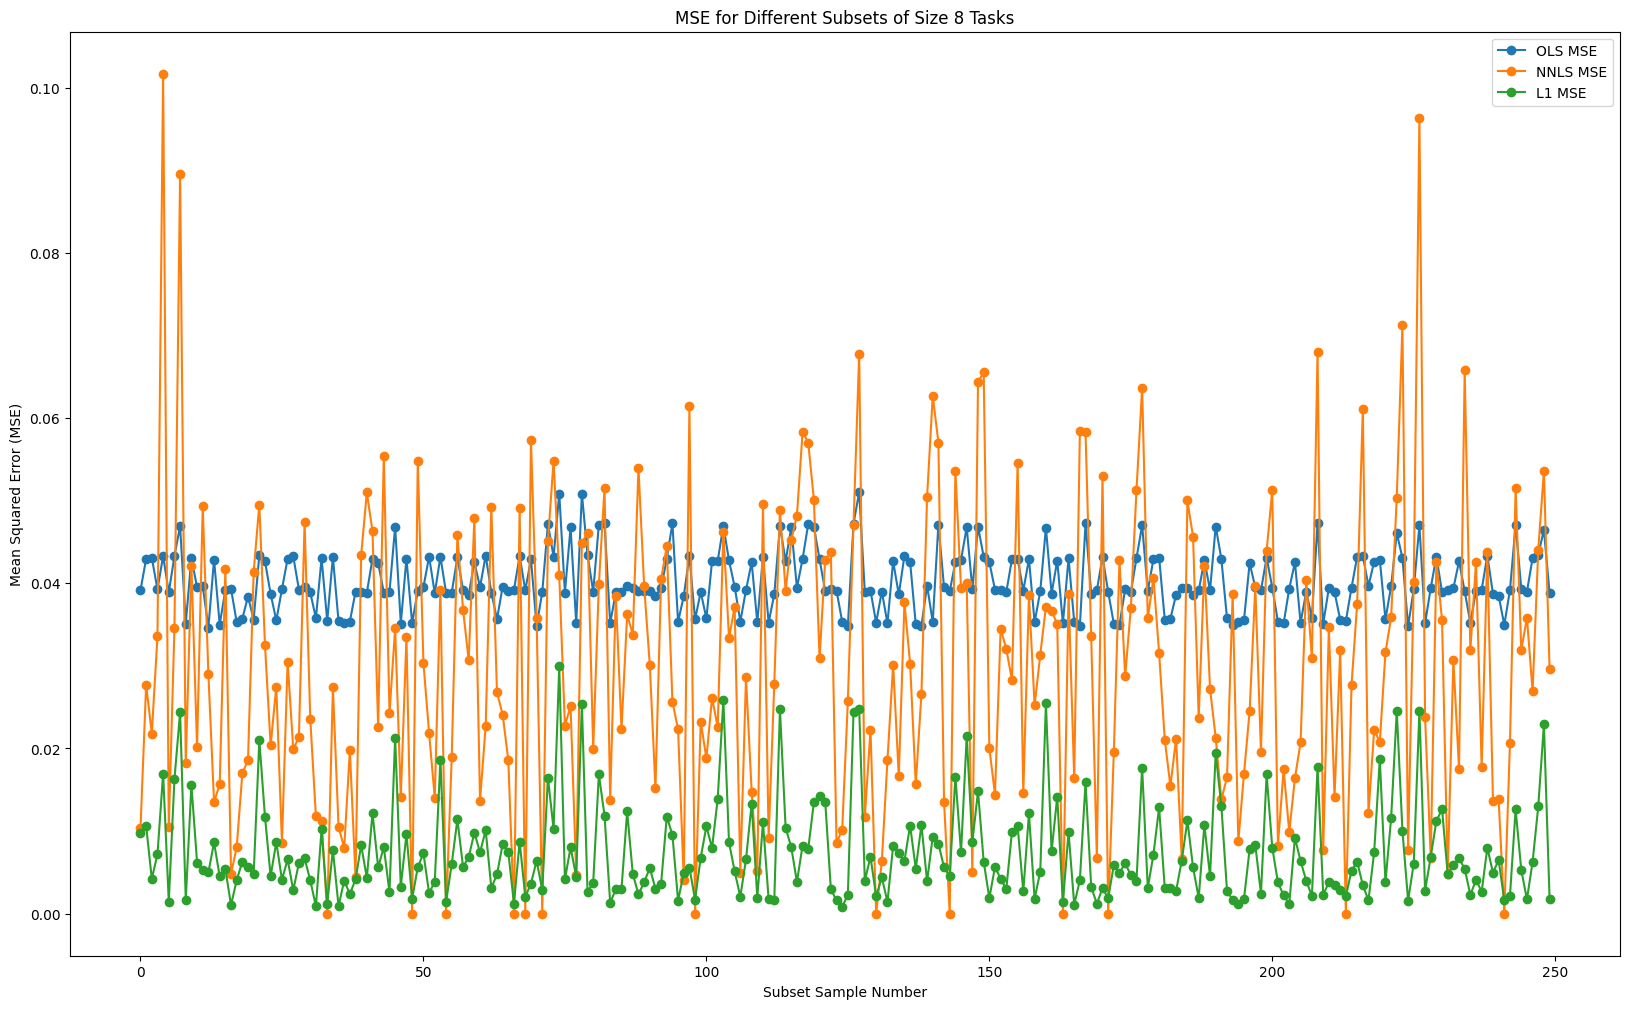

In [22]:
methods = ['OLS', 'NNLS', 'L1']
plt.figure(figsize=(20, 12))

for method in methods:
    if method in results:
        plt.plot(range(n_samples), results[method], 'o-', label=f"{method} MSE")


plt.xlabel('Subset Sample Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE for Different Subsets of Size {subset_size} Tasks')
plt.legend()
plt.show()

In [23]:
methods = ['OLS', 'NNLS', 'L1','L2']
eigen_metrics = ['eig_sum', 'log_det', 'min_est']
correlations = {metric: {} for metric in eigen_metrics}

for metric in eigen_metrics:
    for method in methods:
        corr, _ = pearsonr(results[metric], results[method])
        correlations[metric][method] = corr
        print(f"Correlation between {metric} and {method} MSE: {corr:.4f}")

Correlation between eig_sum and OLS MSE: -0.2963
Correlation between eig_sum and NNLS MSE: -0.0571
Correlation between eig_sum and L1 MSE: -0.3507
Correlation between eig_sum and L2 MSE: -0.2967
Correlation between log_det and OLS MSE: -0.9952
Correlation between log_det and NNLS MSE: -0.5386
Correlation between log_det and L1 MSE: -0.7578
Correlation between log_det and L2 MSE: -0.9953
Correlation between min_est and OLS MSE: 0.9970
Correlation between min_est and NNLS MSE: 0.5364
Correlation between min_est and L1 MSE: 0.7510
Correlation between min_est and L2 MSE: 0.9971


# construct V test / Y test

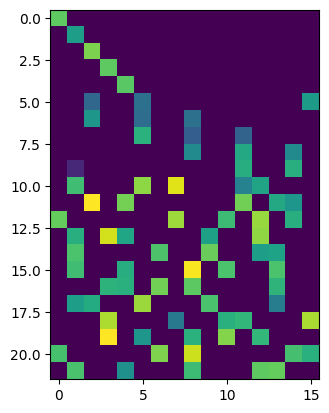

In [27]:
V_test = generate_V(n_tasks=22, n_parcels = 16, seed=2)
plt.imshow(V_test)


In [28]:
Y_test = V_test @ Us
noise_std = 1
noise = np.random.normal(loc=0.0, scale=noise_std, size=Y_test.shape)
Y_test_noisy = Y_test + noise

# cosine similarity

In [32]:
# make into tensors
Y_test = pt.tensor(Y_test, dtype=pt.float32)
V_test = pt.tensor(V_test, dtype=pt.float32)
Y_test_noisy = pt.tensor(Y_test_noisy, dtype=pt.float32)
Us = pt.tensor(Us, dtype=pt.float32)
U_hat_ols = pt.tensor(U_hat_ols, dtype=pt.float32)
U_hat_NNLS = pt.tensor(U_hat_NNLS, dtype=pt.float32)
U_hat_l2 = pt.tensor(U_hat_l2, dtype=pt.float32)


C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\542260152.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_test = pt.tensor(Y_test, dtype=pt.float32)
C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\542260152.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  V_test = pt.tensor(V_test, dtype=pt.float32)
C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\542260152.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Us = pt.tensor(Us, dtype=pt.float32)
C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\542260152.py:6: UserWar

In [33]:
cos = ev.cosine_error(Y_test_noisy, V_test, U_hat_ols,adjusted= False, type='expected')
print("Cosine error ols:", cos.mean())

cos = ev.cosine_error(Y_test_noisy, V_test, U_hat_NNLS,adjusted= False, type='expected')
print("Cosine error NNLS:", cos.mean())

cos = ev.cosine_error(Y_test_noisy, V_test, U_hat_l2,adjusted= False, type='expected')
print("Cosine error L2:", cos.mean())


Cosine error ols: tensor(0.6218)
Cosine error NNLS: tensor(0.6582)
Cosine error L2: tensor(0.6706)


# Now do this on different task batteries

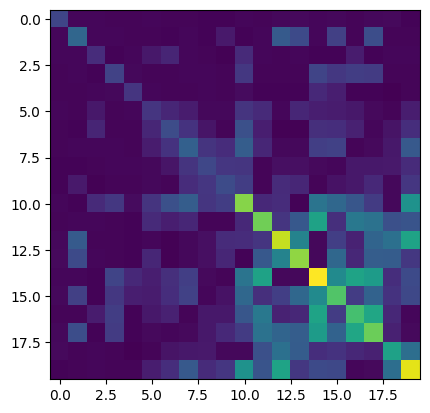

In [34]:
cov_lsit = []
for i in range(y.shape[0]):
    cov = y_noisy[i] @ y_noisy[i].T
    cov_lsit.append(cov)
cov_matrix = np.stack(cov_lsit, axis=0)
cov_matrix = np.mean(cov_matrix, axis=0)

plt.imshow(cov_matrix)

In [65]:
D = ut.build_combinations(cov_matrix, strategy='random',n_iter=30,n_tasks=4,seed=1)

In [66]:
counter = 0
def evaluate_cos(combination):
    global counter
    counter += 1
    print("Iteration:", counter)
    vtrain = V[combination]
    ytrain = y_noisy[:,combination,:]

    U_hat_NNLS = sim.estimate_Us_NNLS(ytrain, vtrain,max_iter=100, tol=1e-6, learning_rate=1e-3)

    ytest = Y_test_noisy
    vtest = V_test

    U_hat_NNLS = pt.tensor(U_hat_NNLS, dtype=pt.float32)
    ytest = pt.tensor(ytest, dtype=pt.float32)
    vtest = pt.tensor(vtest, dtype=pt.float32)

    cos = ev.cosine_error(ytest, vtest, U_hat_NNLS,adjusted= False, type='expected')

    return cos.mean().numpy()

    


In [67]:
unique_combinations_df = D[D['offset'] == D['offset'].min()].copy()
unique_combinations_df['cos'] = unique_combinations_df['combination'].apply(evaluate_cos)

Iteration: 1


C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\1004239768.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest, dtype=pt.float32)
C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\1004239768.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest, dtype=pt.float32)


Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30


In [68]:
D['combination'] = D['combination'].apply(tuple)
unique_combinations_df['combination'] = unique_combinations_df['combination'].apply(tuple)

# Now perform the merge operation using the tuple values
D = D.merge(
    unique_combinations_df[['combination', 'cos']], 
    on='combination', 
    how='left'
)

In [69]:
A = D[D['offset'] == 0.001].copy()

In [72]:
# get the two variables for Dcbc and log_det
log_det_list = A['log_det'].values
dcbc_list = A['cos'].values

from scipy.stats import pearsonr
r_value, p_value = pearsonr(log_det_list, dcbc_list)

print(f"Correlation between log_det and cos: {r_value}, p-value: {p_value}")

Correlation between log_det and cos: -0.3774475181584806, p-value: 0.039755267967736034


In [73]:
# get the two variables for DCBC and min_est
min_est_list = A['min_est'].values
dcbc_list = A['cos'].values

r_value, p_value = pearsonr(min_est_list, dcbc_list)

print(f"Correlation between min_est and cos: {r_value}, p-value: {p_value}")

Correlation between min_est and cos: 0.1803339229068667, p-value: 0.34028180443391964


In [74]:
# get the two variables for DCBC and max_var
max_var_list = A['max_var'].values
dcbc_list = A['cos'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and cos: {r_value}, p-value: {p_value}")

Correlation between max_var and cos: -0.8795611161649394, p-value: 1.561702942157151e-10


In [75]:
# get the two variables for DCBC and max_var
max_var_list = A['off_diag'].values
dcbc_list = A['cos'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and cos: {r_value}, p-value: {p_value}")

Correlation between max_var and cos: -0.4647664221915216, p-value: 0.009663673398751134


#